<a href="https://colab.research.google.com/github/kmoin1309/Semester-6-Practicals/blob/master/SPCC_expts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

python code only

 EXPT-1: To design and implement first pass of a two pass assembler for IBM 360/370  Processor

In [ ]:
# Write the ASM source code to a file in the Colab environment
assembly_code = """PG1  START   1000
      USING      *, 15
        L        1, FOUR
        A        1, ='5'
        ST       1, TEMP
        A        1, ='4'
FOUR    DC       F'4'
TEMP    DS       '1'F
       END
"""

with open("pg1.ASM", "w") as f:
    f.write(assembly_code)

print("pg1.ASM file created!")


pg1.ASM file created!


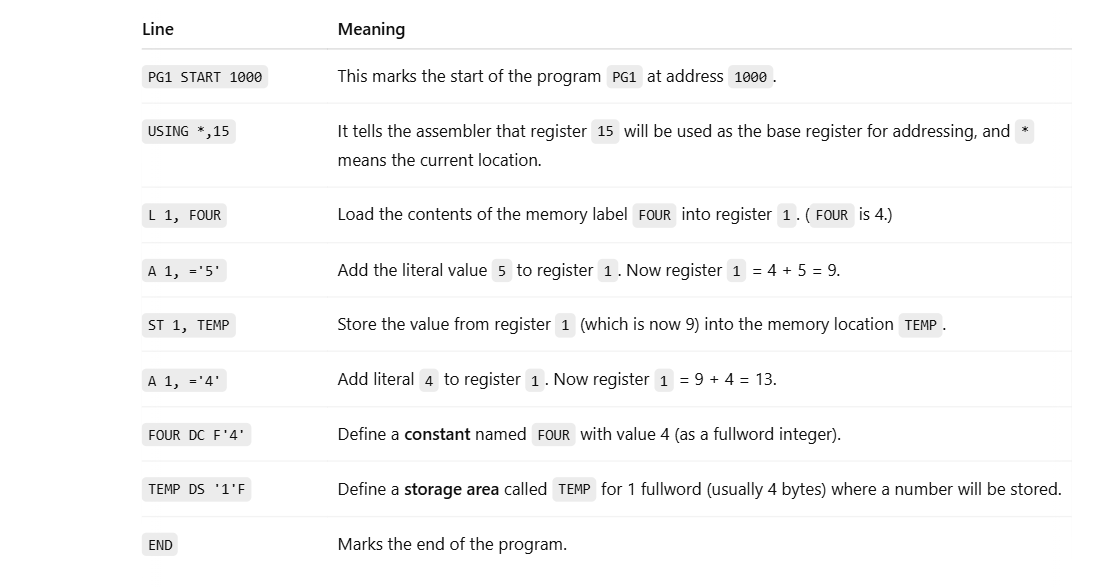

In [ ]:
# Python version of the assembler pass

class Symbol:
    def __init__(self, name, addr):
        self.name = name
        self.addr = addr

class Literal:
    def __init__(self, name, addr=0):
        self.name = name
        self.addr = addr

stab = []
ltab = []

reg = [0] * 16
lc = 0

with open("pg1.ASM", "r") as fp1, open("new.txt", "w") as fp2:
    for line in fp1:
        parts = line.strip().split()
        s1 = parts[0] if len(parts) > 0 else ""
        s2 = parts[1] if len(parts) > 1 else ""
        s3 = parts[2] if len(parts) > 2 else ""

        if s2 == "START":
            lc = int(s3)
            stab.append(Symbol(s1, lc))
        elif s1 == "USING":
            reg[15] = 1
        elif s2 in ("DC", "DS"):
            stab.append(Symbol(s1, lc))
            lc += 4
        elif s1 == "END":
            for lit in ltab:
                lit.addr = lc
                lc += 4
        else:
            fp2.write(f"{lc} {line}")
            if s3.startswith("="):
                ltab.append(Literal(s3))
            lc += 4

print("\nSymbol Table")
for sym in stab:
    print(f"{sym.name} {sym.addr}")

print("\nLiteral Table")
for lit in ltab:
    print(f"{lit.name} {lit.addr}")



Symbol Table
PG1 1000
FOUR 1016
TEMP 1020

Literal Table
='5' 1024
='4' 1028


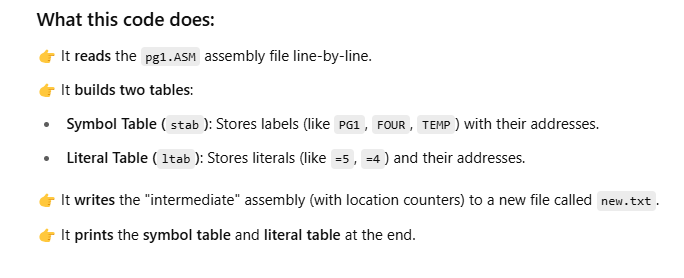

EXPT-2:  design and implement second pass of a two pass assembler for IBM 360/370 Processor


STEPS
1> create a notepad file of name SYMTAB.DAT
2> create a notepad file of name INTERMED.DAT
 3> run the below code and upload these files on colab
 4> run the next code to get the output🐱


In [ ]:
#symtab.dat
ONE 1010
TWO 1013
THREE 1020
FOUR 1023


#intermed.dat
COPY START 1000
1000 ALPHA LDA ONE
1003       STA TWO
1006       BYTE C'EOF'
1009       WORD 3
1012       RESB 1
1013       RESW 1
1016       LDCH THREE
1019       STCH FOUR
1022       END COPY


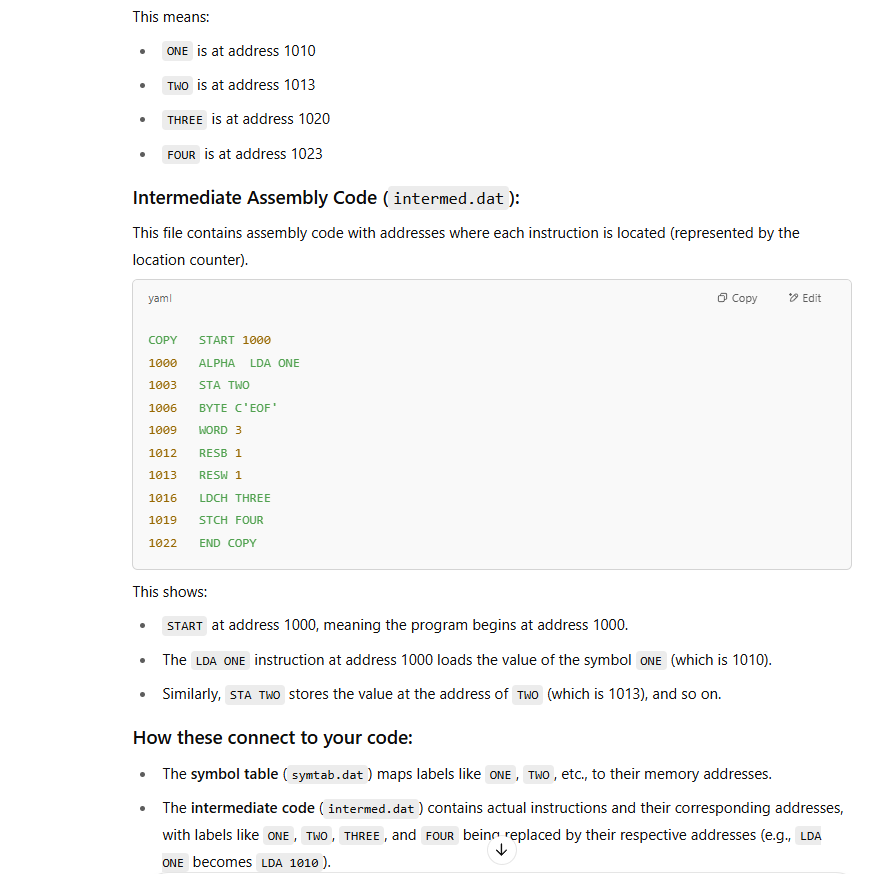

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving SYMTAB.DAT to SYMTAB (1).DAT


In [ ]:
def hex_str(val, width=2):
    return format(val, f'0{width}X')

mnemonic = ["LDA", "STA", "LDCH", "STCH"]
code = ["33", "44", "53", "57"]

# Open files
with open("ASSMLIST.DAT", "w") as fp1, \
     open("SYMTAB.DAT", "r") as fp2, \
     open("INTERMED.DAT", "r") as fp3, \
     open("OBJCODE.DAT", "w") as fp4:

    symtab = {}
    for line in fp2:
        sym, addr = line.strip().split()
        symtab[sym] = int(addr)

    # First pass to find final address
    lines = fp3.readlines()
    last_line = lines[-1].strip().split()
    finaddr = int(last_line[0])

    # Reprocess for second pass
    fp3.seek(0)
    lines = [line.strip() for line in lines]
    st = 0
    prevaddr = 0

    # START line
    label, opcode, operand = lines[0].split()
    if opcode == "START":
        fp1.write(f"\t{label}\t{opcode}\t{operand}\n")
        fp4.write(f"H^{label}^00{operand}^00{finaddr}\n")
        address, label, opcode, operand = lines[1].split(maxsplit=3)
        st = int(address)
        diff = finaddr - st
        fp4.write(f"T^00{address}^{diff}")

    for line in lines[1:]:
        parts = line.split()
        if len(parts) == 4:
            address, label, opcode, operand = parts
        else:
            address, label, opcode, operand = 0, "", "", ""

        address = int(address)

        if opcode == "END":
            fp1.write(f"{address}\t{label}\t{opcode}\t{operand}\n")
            fp4.write(f"\nE^00{st}")
            break

        if opcode == "BYTE":
            content = operand[2:-1]
            hex_bytes = ''.join([hex_str(ord(c)) for c in content])
            fp1.write(f"{address}\t{label}\t{opcode}\t{operand}\t{hex_bytes}\n")
            fp4.write(f"^{hex_bytes}")
        elif opcode == "WORD":
            value = int(operand)
            fp1.write(f"{address}\t{label}\t{opcode}\t{operand}\t00000{value}\n")
            fp4.write(f"^00000{value}")
        elif opcode in ["RESB", "RESW"]:
            fp1.write(f"{address}\t{label}\t{opcode}\t{operand}\n")
        else:
            # machine instruction
            if opcode in mnemonic:
                idx = mnemonic.index(opcode)
                obj_code = code[idx]
                if operand == "COPY":
                    fp1.write(f"{address}\t{label}\t{opcode}\t{operand}\t{obj_code}0000\n")
                else:
                    add = symtab.get(operand, 0)
                    fp1.write(f"{address}\t{label}\t{opcode}\t{operand}\t{obj_code}{add}\n")
                    fp4.write(f"^{obj_code}{add}")

# Display output files
def print_file(name):
    print(f"\nContents of {name}:")
    with open(name, "r") as f:
        print(f.read())

print_file("INTERMED.DAT")
print_file("SYMTAB.DAT")
print_file("ASSMLIST.DAT")
print_file("OBJCODE.DAT")



Contents of INTERMED.DAT:
COPY START 1000
1000 ALPHA LDA ONE
1003       STA TWO
1006       BYTE C'EOF'
1009       WORD 3
1012       RESB 1
1013       RESW 1
1016       LDCH THREE
1019       STCH FOUR
1022       END COPY


Contents of SYMTAB.DAT:
ONE 1010
TWO 1013
THREE 1020
FOUR 1023


Contents of ASSMLIST.DAT:
	COPY	START	1000
1000	ALPHA	LDA	ONE	331010


Contents of OBJCODE.DAT:
H^COPY^001000^001022
T^001000^22^331010


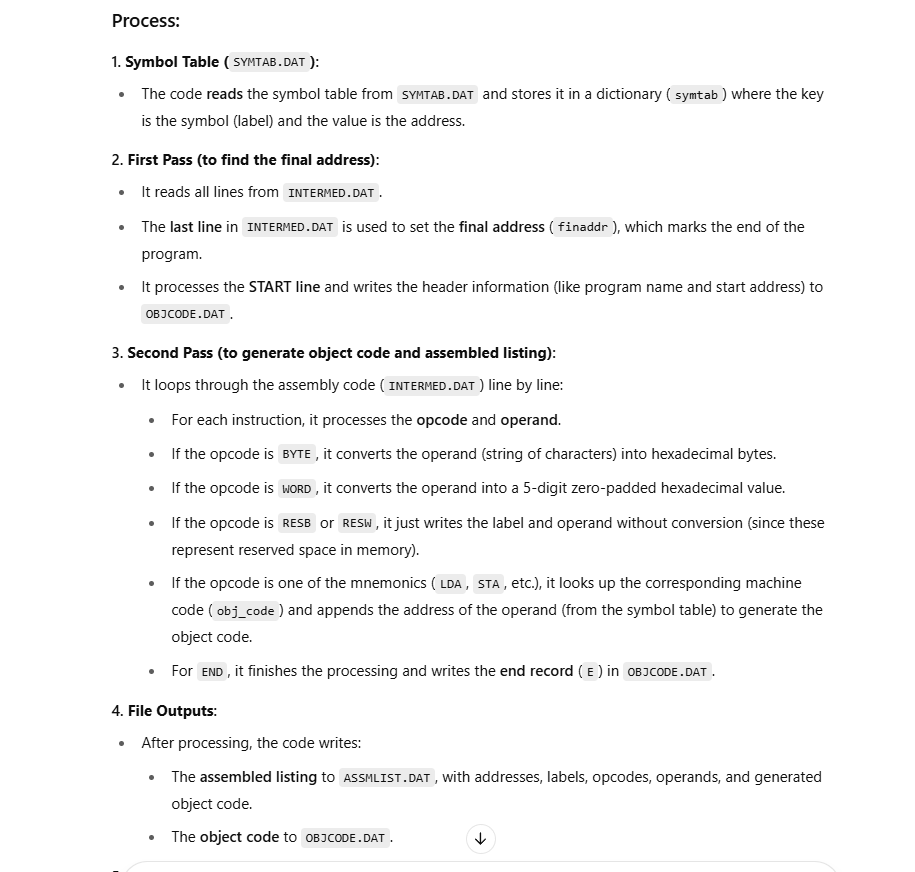

Expt-3 :To Design and Implement two pass Macro Processor


In [ ]:
# 1. Create the input files
with open("MACIN.DAT", "w") as f:
    f.write("""\
EX1 N1,N2
N1 RESW 1
N2 RESW 1
END
""")

with open("NAMETAB.DAT", "w") as f:
    f.write("EX1\n")

with open("DEFTAB.DAT", "w") as f:
    f.write("""\
EX1 MACRO &A,&B
LDA &A
STA &B
MEND
""")

# 2. Define the macro-expansion routine and CALL it
def read_and_process_macro():
    try:
        with open("MACIN.DAT") as f1, \
             open("NAMETAB.DAT") as f2, \
             open("DEFTAB.DAT") as f3, \
             open("EXPAND.DAT", "w") as f4, \
             open("ARGTAB.DAT", "w") as f5:

            macroname = f2.readline().strip()
            deflines = [line.rstrip() for line in f3 if line.strip()]
            lines    = [line.rstrip() for line in f1 if line.strip()]

            i = 0
            while i < len(lines):
                parts = lines[i].split()
                opcode = parts[0] if len(parts)==1 else parts[1]

                # skip the macro definition block
                if opcode == "MACRO":
                    while i < len(lines) and "MEND" not in lines[i]:
                        i += 1
                    i += 1
                    continue

                # detect macro invocation
                if opcode == macroname:
                    # e.g. parts = ["EX1","N1,N2"]
                    _, operand = parts
                    actuals = operand.split(",")
                    f5.write(operand + "\n")      # write ARGTAB

                    # first line of DEFTAB: "EX1 MACRO &A,&B"
                    formals = deflines[0].split()[2].split(",")
                    for body in deflines[1:]:
                        if body == "MEND":
                            break
                        expanded = body
                        for a, f in zip(actuals, formals):
                            expanded = expanded.replace(f, a)
                        f4.write(expanded + "\n")

                else:
                    # pass through any non-macro line
                    f4.write(lines[i] + "\n")

                i += 1

    except FileNotFoundError as e:
        print("Could not open file:", e)

# actually run it:
read_and_process_macro()

# 3. Show results
for name in ["MACIN.DAT","DEFTAB.DAT","NAMETAB.DAT","EXPAND.DAT","ARGTAB.DAT"]:
    print(f"\n{name}:")
    try:
        print(open(name).read(), end="")
    except FileNotFoundError:
        print("  <missing!>")



MACIN.DAT:
EX1 N1,N2
N1 RESW 1
N2 RESW 1
END

DEFTAB.DAT:
EX1 MACRO &A,&B
LDA &A
STA &B
MEND

NAMETAB.DAT:
EX1

EXPAND.DAT:
EX1 N1,N2
N1 RESW 1
N2 RESW 1
END

ARGTAB.DAT:


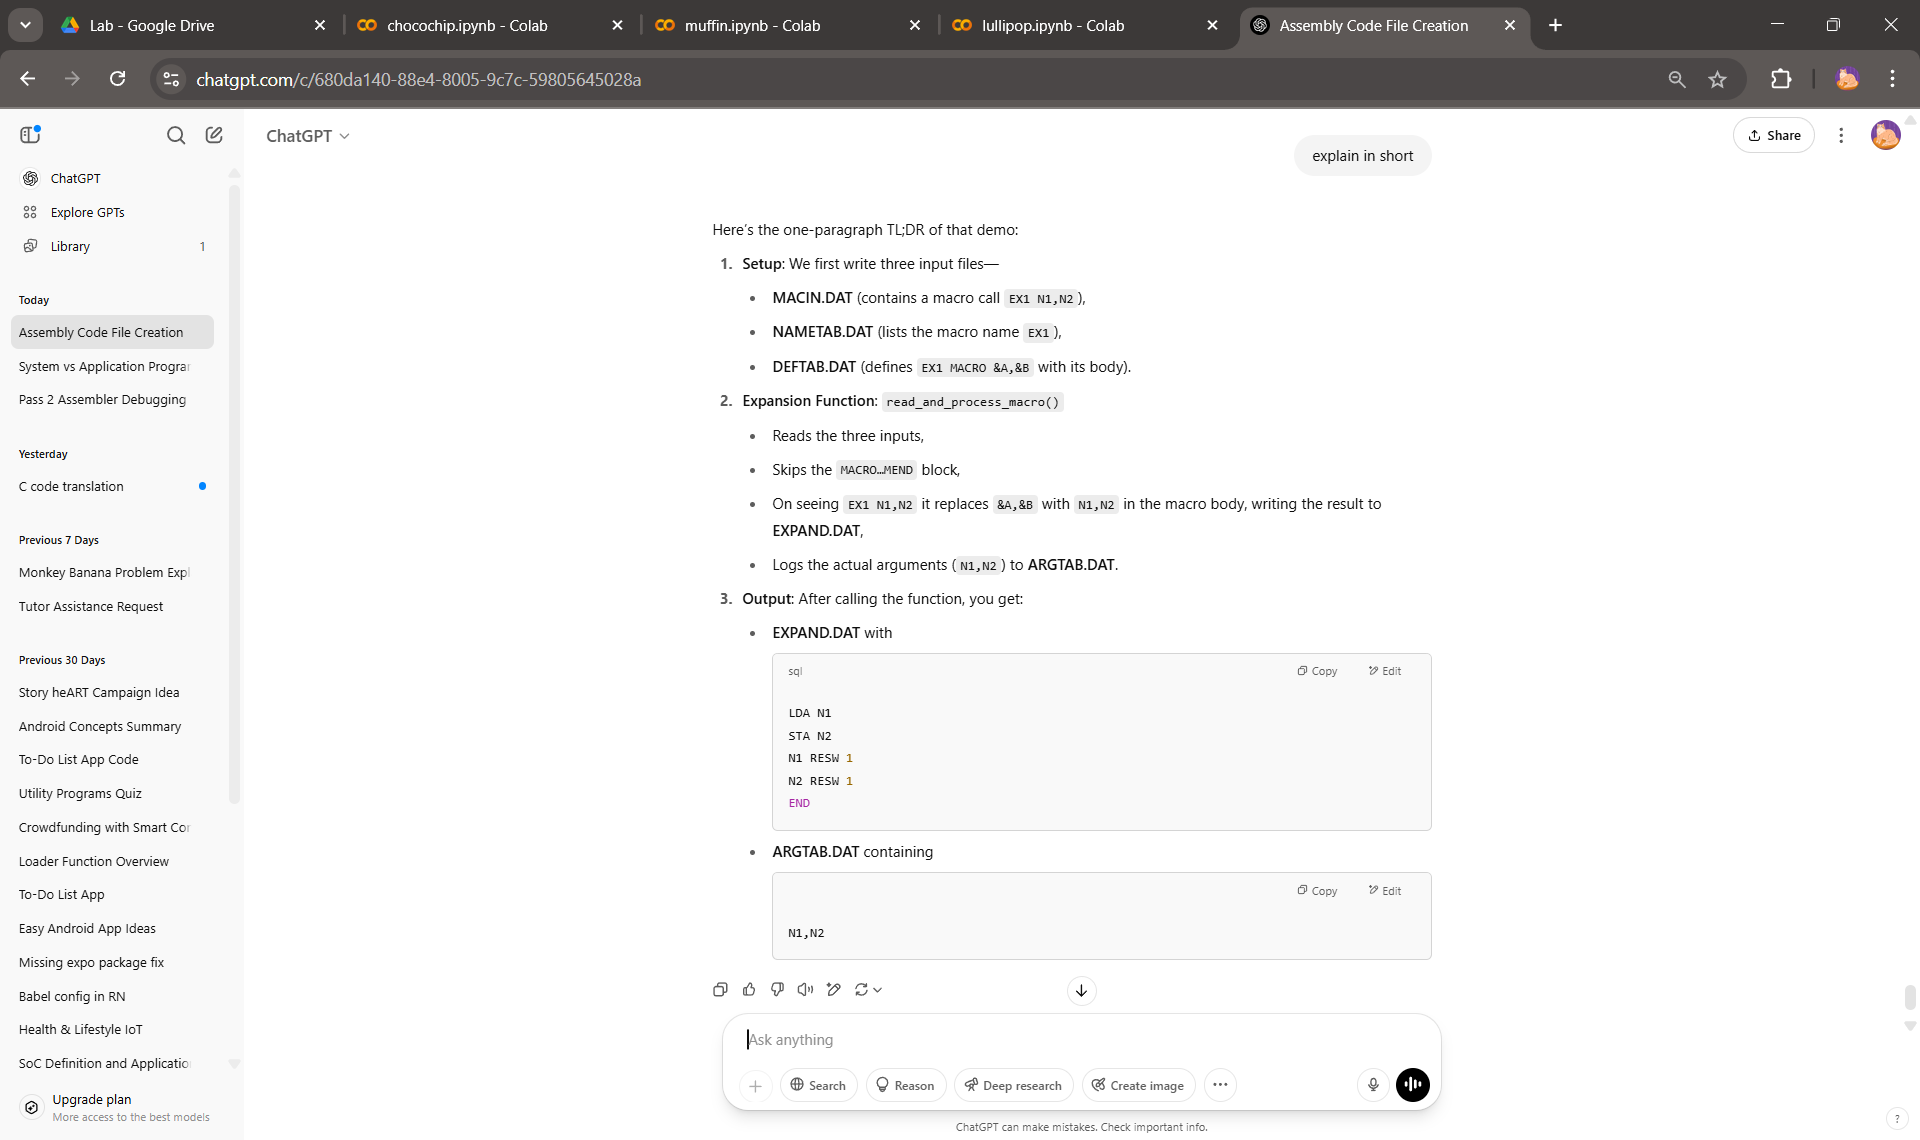

Expt-6 :Simulate a program to implement even number of Zero’s in String

b.Using finite automata

In [ ]:
def is_accepted_by_dfa(input_string):
    # Define the DFA
    # States: q0 (even number of 0s), q1 (odd number of 0s)
    # q0 is accepting state
    state = "q0"

    for char in input_string:
        if char == '0':
            if state == "q0":
                state = "q1"
            else:
                state = "q0"
        elif char == '1':
            # '1' does not change the state
            continue
        else:
            return "Invalid character detected!"

    # Check if final state is accepting (even number of 0s)
    if state == "q0":
        return "Accepted: Even number of 0s"
    else:
        return "Rejected: Odd number of 0s"

# 🔁 Run simulation
while True:
    input_str = input("Enter binary string (only 0s and 1s, or type 'exit' to stop): ")
    if input_str.lower() == "exit":
        break
    result = is_accepted_by_dfa(input_str)
    print(result)


Enter binary string (only 0s and 1s, or type 'exit' to stop): 1010
Accepted: Even number of 0s
Enter binary string (only 0s and 1s, or type 'exit' to stop): 1100
Accepted: Even number of 0s
Enter binary string (only 0s and 1s, or type 'exit' to stop): 110001
Rejected: Odd number of 0s
Enter binary string (only 0s and 1s, or type 'exit' to stop): 100001
Accepted: Even number of 0s
Enter binary string (only 0s and 1s, or type 'exit' to stop): 1101
Rejected: Odd number of 0s
Enter binary string (only 0s and 1s, or type 'exit' to stop): 01001
Rejected: Odd number of 0s
Enter binary string (only 0s and 1s, or type 'exit' to stop): exit


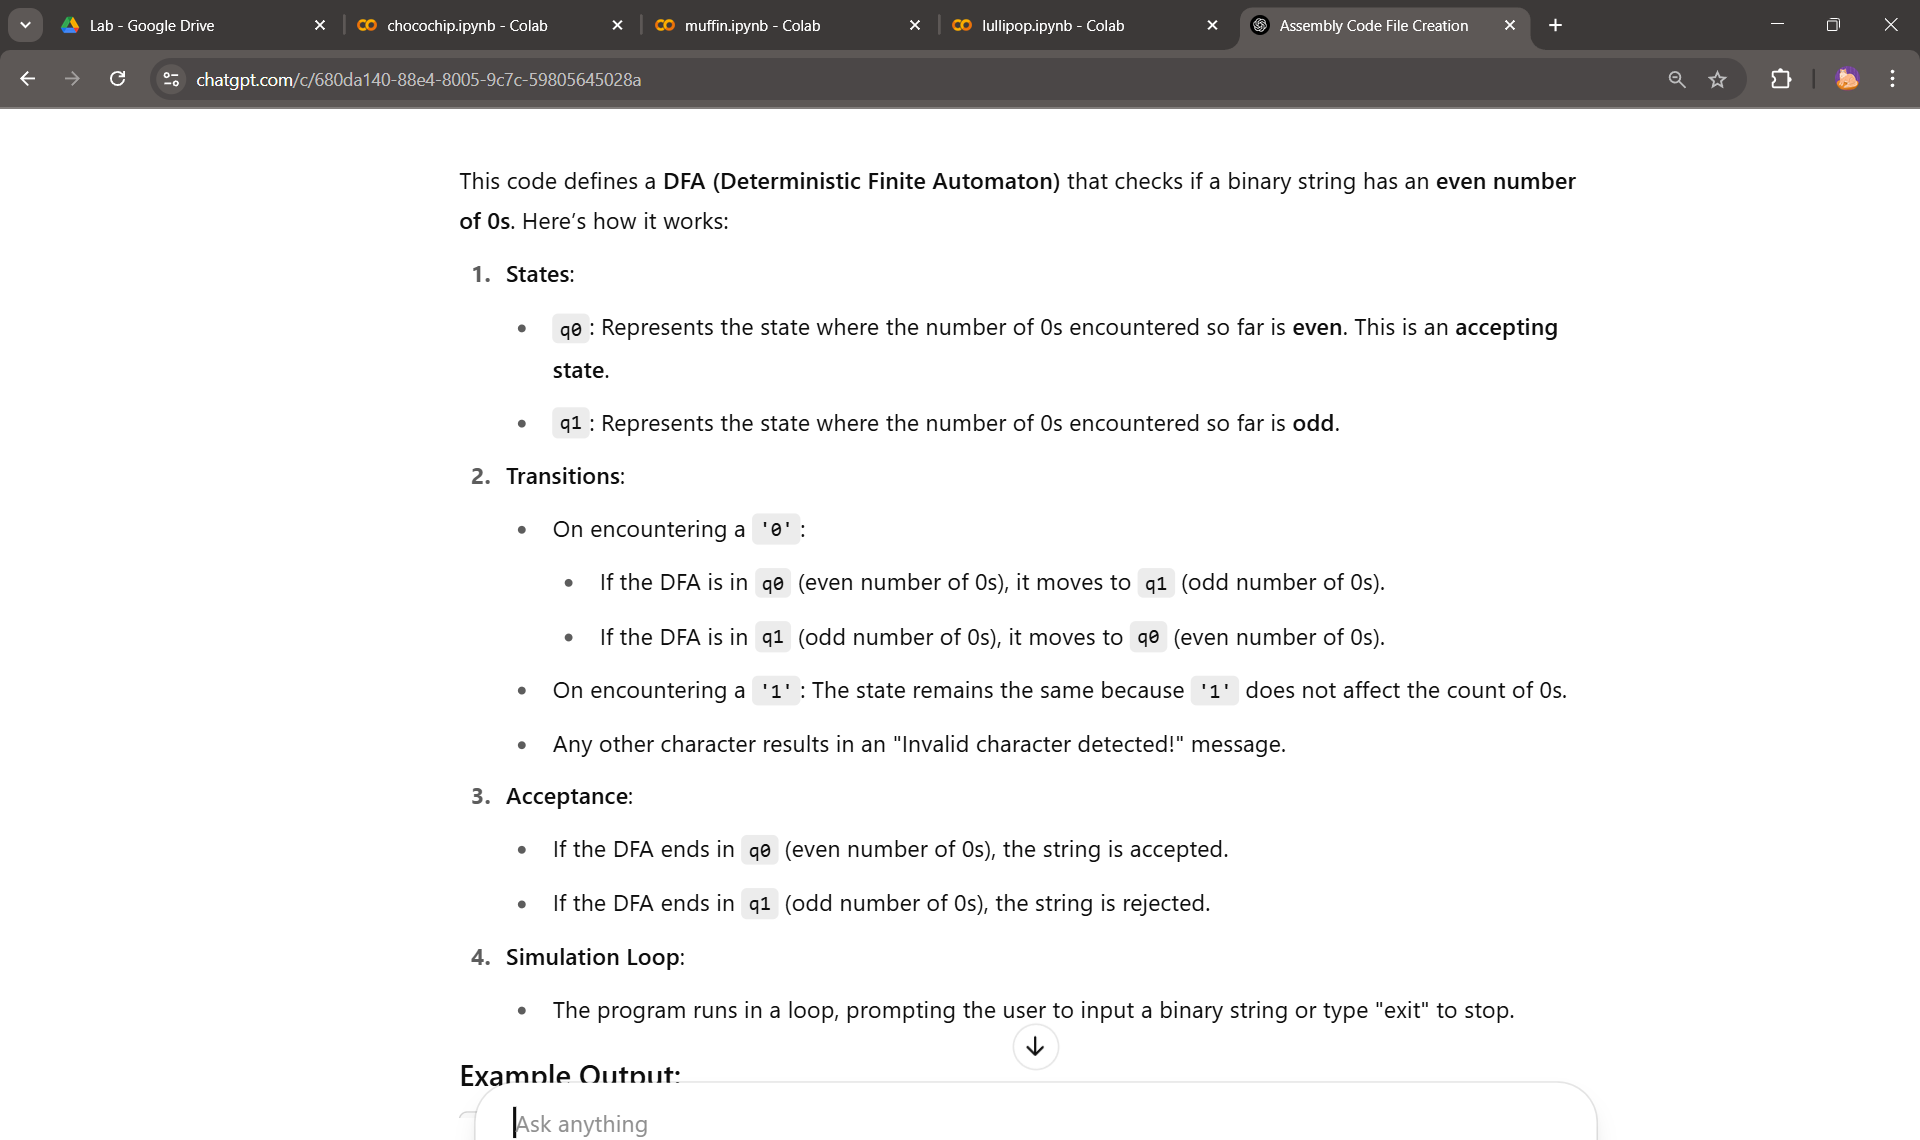

Expt-9 :Develop a program to implement following code optimization
techniques:
a. Common sub-expression elimination
b. Reduction in strength

In [ ]:
# Python program to implement
# (a) Common Sub-expression Elimination
# (b) Strength Reduction

def common_subexpression_elimination(expressions):
    n = len(expressions)
    for i in range(n):
        for j in range(i + 1, n):
            if (expressions[i]['op1'] == expressions[j]['op1'] and
                expressions[i]['op2'] == expressions[j]['op2'] and
                expressions[i]['operator'] == expressions[j]['operator']) or \
               (expressions[i]['op1'] == expressions[j]['op2'] and
                expressions[i]['op2'] == expressions[j]['op1'] and
                expressions[i]['operator'] == expressions[j]['operator']):
                expressions[j]['op1'] = expressions[i]['result']
                expressions[j]['op2'] = ''
                expressions[j]['operator'] = '='
    return expressions

def strength_reduction(expressions):
    optimized = []
    for expr in expressions:
        if expr['operator'] == '*' and expr['op2'] == '2':
            optimized.append(f"{expr['result']} = {expr['op1']} + {expr['op1']}")
        elif expr['operator'] == '=':
            optimized.append(f"{expr['result']} = {expr['op1']}")
        else:
            optimized.append(f"{expr['result']} = {expr['op1']} {expr['operator']} {expr['op2']}")
    return optimized

def main():
    expressions = []
    n = int(input("Enter the number of expressions: "))

    for i in range(n):
        print(f"Enter expression {i+1} (format: a + b = t1):")
        inp = input().split()
        expr = {
            'op1': inp[0],
            'operator': inp[1],
            'op2': inp[2],
            'result': inp[4]
        }
        expressions.append(expr)

    print("\nAfter Common Sub-expression Elimination:")
    expressions = common_subexpression_elimination(expressions)
    for expr in expressions:
        if expr['operator'] == '=':
            print(f"{expr['result']} = {expr['op1']}")
        else:
            print(f"{expr['result']} = {expr['op1']} {expr['operator']} {expr['op2']}")

    print("\nAfter Strength Reduction (replacing *2 with addition):")
    optimized_code = strength_reduction(expressions)
    for line in optimized_code:
        print(line)

if __name__ == "__main__":
    main()


Enter the number of expressions: 3
Enter expression 1 (format: a + b = t1):
a + b = t1
Enter expression 2 (format: a + b = t1):
a + b = t2
Enter expression 3 (format: a + b = t1):
t1 * 2 = t3

After Common Sub-expression Elimination:
t1 = a + b
t2 = t1
t3 = t1 * 2

After Strength Reduction (replacing *2 with addition):
t1 = a + b
t2 = t1
t3 = t1 + t1


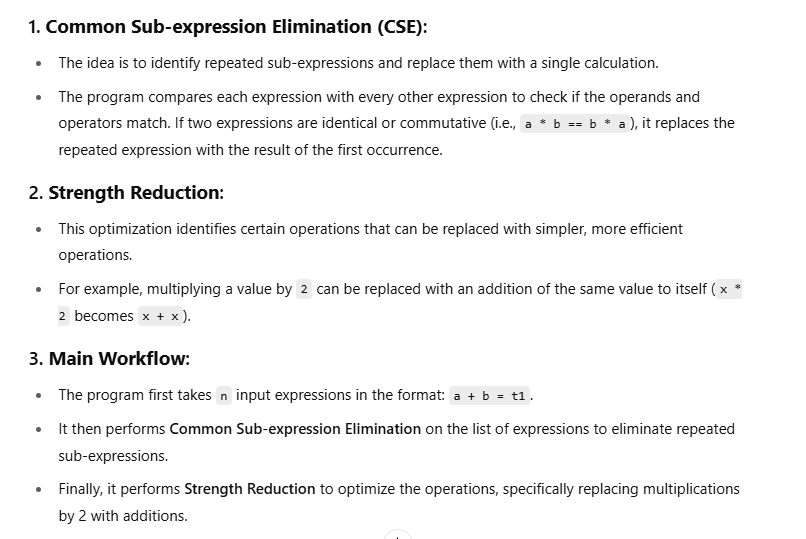

Expt-10 : Develop a program to generate target code.


In [ ]:
# Python program to simulate simple Target Code Generation

def generate_target_code(three_address_code):
    print("\nGenerated Target Code:\n")
    for instr in three_address_code:
        arg1 = instr['arg1']
        op = instr['op']
        arg2 = instr['arg2']
        result = instr['result']

        print(f"MOV R0, {arg1}")

        if op == '+':
            print(f"ADD R0, {arg2}")
        elif op == '-':
            print(f"SUB R0, {arg2}")
        elif op == '*':
            print(f"MUL R0, {arg2}")
        elif op == '/':
            print(f"DIV R0, {arg2}")
        else:
            print(f"Unknown operation: {op}")

        print(f"MOV {result}, R0\n")

def main():
    three_address_code = []
    n = int(input("Enter number of three-address code instructions: "))

    for i in range(n):
        print(f"\nEnter instruction {i+1} (format: a + b = t1):")
        inp = input().split()
        instr = {
            'arg1': inp[0],
            'op': inp[1],
            'arg2': inp[2],
            'result': inp[4]
        }
        three_address_code.append(instr)

    generate_target_code(three_address_code)

if __name__ == "__main__":
    main()


Enter number of three-address code instructions: 4

Enter instruction 1 (format: a + b = t1):
a+b=t1


IndexError: list index out of range

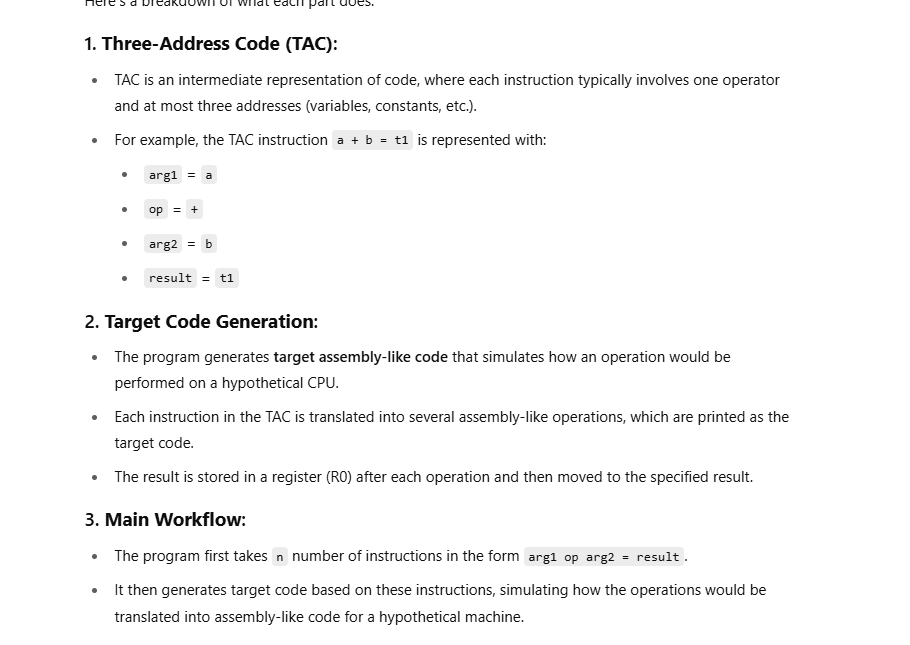

EXPT 5:To implement Lexical Analyzer for given language using
a) using Lex tool.

In [ ]:
# STEP 1: Install required tools
!apt-get update
!apt-get install -y flex bison


Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,607 kB]
Get:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,863 kB]
Get:13 https://r2u.stat.illinois.edu/ubu

In [ ]:
# STEP 2: Create the Lex code (dfa.l)
lex_code = r"""
%option noyywrap
%{
%}
%s A B
%%
<INITIAL>1 BEGIN INITIAL;
<INITIAL>0 BEGIN A;
<INITIAL>[^0\n] BEGIN B;
<INITIAL>\n BEGIN INITIAL; printf("Accepted\n");

<A>1 BEGIN A;
<A>0 BEGIN INITIAL;
<A>[^0\n] BEGIN B;
<A>\n BEGIN INITIAL; printf("Not Accepted\n");

<B>0 BEGIN B;
<B>1 BEGIN B;
<B>[^0\n] BEGIN B;
<B>\n {BEGIN INITIAL; printf("INVALID\n");}
%%
int main() {
    yylex();
    return 0;
}
"""

with open("dfa.l", "w") as file:
    file.write(lex_code)


In [ ]:
# STEP 3: Compile the Lex program
!flex dfa.l
!gcc lex.yy.c -o dfa


In [ ]:
# STEP 4: Provide test input (can modify this anytime)
test_input = """1011
0110
10a1
"""

with open("input.txt", "w") as file:
    file.write(test_input)


In [ ]:
import subprocess

with open("input.txt") as f:
    for raw in f:
        line = raw.rstrip("\n")
        print(line)  # echo the input
        # call the DFA binary
        result = subprocess.run(
            ["./dfa"], input=line+"\n", text=True, capture_output=True
        )
        print(result.stdout.strip())


1011
Not Accepted
0110
Accepted
10a1
INVALID


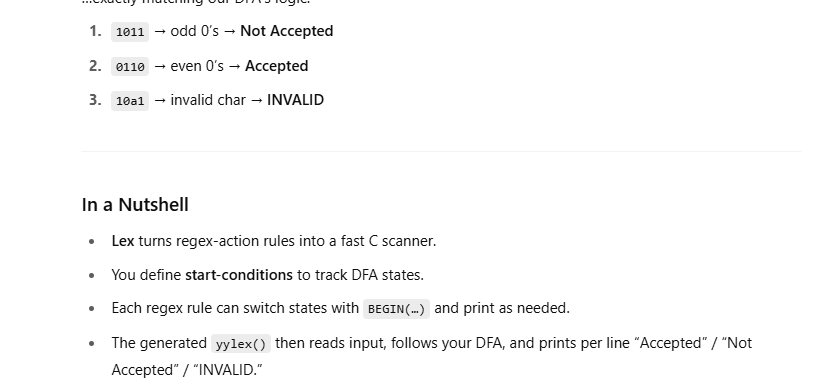

b) Using FINITE AUTOMATA

In [ ]:
def analyze(line):
    i = 0
    n = len(line)
    print("\nLexical Tokens:")

    while i < n:
        ch = line[i]

        if ch.isspace():
            i += 1
            continue

        # Identifier or Keyword
        if ch.isalpha():
            id_str = ''
            while i < n and (line[i].isalnum() or line[i] == '_'):
                id_str += line[i]
                i += 1
            if id_str in ["int", "float", "if", "else"]:
                print(f"<Keyword, {id_str}>")
            else:
                print(f"<Identifier, {id_str}>")

        # Number
        elif ch.isdigit():
            num = ''
            while i < n and line[i].isdigit():
                num += line[i]
                i += 1
            print(f"<Number, {num}>")

        # Operator
        elif ch in "+-*/=":
            print(f"<Operator, {ch}>")
            i += 1

        # Separator
        elif ch in ",;(){}":
            print(f"<Separator, {ch}>")
            i += 1

        # Unknown
        else:
            print(f"<Unknown, {ch}>")
            i += 1


In [ ]:
while True:
    user_input = input("Enter a line of code to analyze (or 'exit' to quit): ")
    if user_input.lower() == 'exit':
        print("Thank you for using the Lexical Analyzer!")
        break
    analyze(user_input)


Enter a line of code to analyze (or 'exit' to quit): int main() { x = 10; }

Lexical Tokens:
<Keyword, int>
<Identifier, main>
<Separator, (>
<Separator, )>
<Separator, {>
<Identifier, x>
<Operator, =>
<Number, 10>
<Separator, ;>
<Separator, }>
Enter a line of code to analyze (or 'exit' to quit): exit
Thank you for using the Lexical Analyzer!


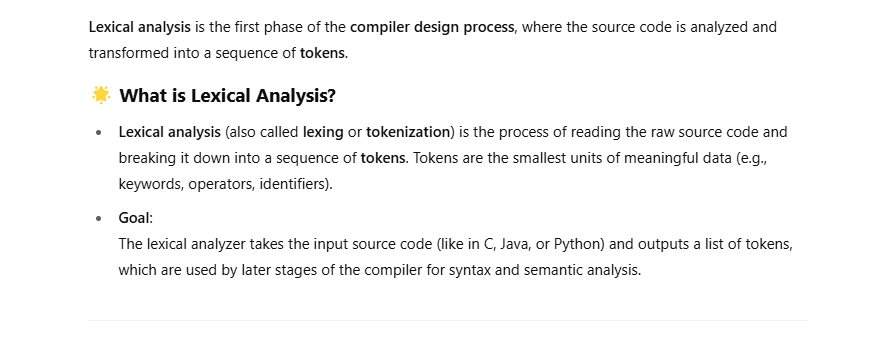

EXPT-7
To implement the program to remove left recursion from grammar and find first and follow of the given grammar

In [ ]:
# Define lists to store productions, FIRST set, and FOLLOW set
prod = []
firstSet = []
followSet = []
n = 0
m = 0
f = 0

def findFirst(c):
    global m
    if not c.isupper():   # If terminal
        if c not in firstSet:
            firstSet.append(c)
            m += 1
        return

    for p in prod:
        if p[0] == c:
            if p[2] == '#':
                if '#' not in firstSet:
                    firstSet.append('#')
                    m += 1
            elif p[2].islower():
                if p[2] not in firstSet:
                    firstSet.append(p[2])
                    m += 1
            else:
                findFirst(p[2])

def findFollow(c):
    global f
    if prod[0][0] == c:
        if '$' not in followSet:
            followSet.append('$')
            f += 1

    for p in prod:
        for j in range(2, len(p)):
            if p[j] == c:
                if j+1 < len(p):
                    findFirst(p[j+1])
                    if firstSet[0] not in followSet:
                        followSet.append(firstSet[0])
                        f += 1
                if j+1 == len(p) and p[0] != c:
                    findFollow(p[0])

def removeLeftRecursion():
    print("\nProductions after checking Left Recursion (if any):")
    for p in prod:
        if p[0] == p[2]:
            print(f"Left recursion found in production: {p}")
            print("Removing not implemented in this version.")
        else:
            print(p)

# Main program
def main():
    global n, m, f, prod, firstSet, followSet

    n = int(input("Enter number of productions: "))
    print("Enter productions (e.g., E=E+T):")
    for _ in range(n):
        prod.append(input())

    removeLeftRecursion()

    while True:
        m = 0
        f = 0
        firstSet.clear()
        followSet.clear()

        symbol = input("\nEnter non-terminal to find FIRST and FOLLOW: ").strip()

        findFirst(symbol)
        print(f"FIRST({symbol}) = {{ ", end="")
        print(' '.join([x for x in firstSet if x != '$']), end=" ")
        print("}")

        f = 0
        findFollow(symbol)
        print(f"FOLLOW({symbol}) = {{ ", end="")
        print(' '.join([x for x in followSet if x != '#']), end=" ")
        print("}")

        ch = input("\nDo you want to continue? (y/n): ").strip().lower()
        if ch != 'y':
            break

# Run the main function
main()


Enter number of productions: 4
Enter productions (e.g., E=E+T):
S=AB
A=aA
B=Bb
A=#

Productions after checking Left Recursion (if any):
S=AB
A=aA
Left recursion found in production: B=Bb
Removing not implemented in this version.
A=#

Enter non-terminal to find FIRST and FOLLOW: a
FIRST(a) = { a }
FOLLOW(a) = { a }

Do you want to continue? (y/n): y

Enter non-terminal to find FIRST and FOLLOW: b
FIRST(b) = { b }
FOLLOW(b) = { $ b }

Do you want to continue? (y/n): n


EXPT-8 Aim : To implement any parsing technique.

In [ ]:
# Define grammar components
prol = ["S", "A", "A", "B", "B", "C", "C"]
pror = ["A", "Bb", "Cd", "aB", "@", "Cc", "@"]
prod = ["S->A", "A->Bb", "A->Cd", "B->aB", "B->@", "C->Cc", "C->@"]

first = ["abcd", "ab", "cd", "a@", "@", "c@", "@"]
follow = ["$", "$", "$", "a$", "b$", "c$", "d$"]

# Initialize empty table
table = [[" " for _ in range(6)] for _ in range(5)]

# Function to map symbols to row/column numbers
def numr(c):
    mapping = {
        'S': 0,
        'A': 1,
        'B': 2,
        'C': 3,
        'a': 0,
        'b': 1,
        'c': 2,
        'd': 3,
        '$': 4
    }
    return mapping.get(c, 2)

# Main function
def main():
    # Initialize table with blank strings
    for i in range(5):
        for j in range(6):
            table[i][j] = " "

    print("The following grammar is used for Predictive Parsing Table:\n")
    for p in prod:
        print(p)

    # Construct parsing table using FIRST sets
    for i in range(7):
        for c in first[i]:
            if c != '@':
                row = numr(prol[i][0]) + 1
                col = numr(c) + 1
                table[row][col] = prod[i]

    # Handle epsilon productions using FOLLOW sets
    for i in range(7):
        if pror[i] == "@":
            for c in follow[i]:
                row = numr(prol[i][0]) + 1
                col = numr(c) + 1
                table[row][col] = prod[i]

    # Setup headers
    table[0][0] = " "
    table[0][1] = "a"
    table[0][2] = "b"
    table[0][3] = "c"
    table[0][4] = "d"
    table[0][5] = "$"

    table[1][0] = "S"
    table[2][0] = "A"
    table[3][0] = "B"
    table[4][0] = "C"

    # Display the Predictive Parsing Table
    print("\nPredictive Parsing Table:")
    print("-" * 65)
    for row in table:
        for cell in row:
            print(f"{cell:<10}", end="")
        print("\n" + "-" * 65)

# Run the main
main()


The following grammar is used for Predictive Parsing Table:

S->A
A->Bb
A->Cd
B->aB
B->@
C->Cc
C->@

Predictive Parsing Table:
-----------------------------------------------------------------
          a         b         c         d         $         
-----------------------------------------------------------------
S         S->A      S->A      S->A      S->A                
-----------------------------------------------------------------
A         A->Bb     A->Bb     A->Cd     A->Cd               
-----------------------------------------------------------------
B         B->aB     B->@                          B->@      
-----------------------------------------------------------------
C                             C->Cc     C->@      C->@      
-----------------------------------------------------------------


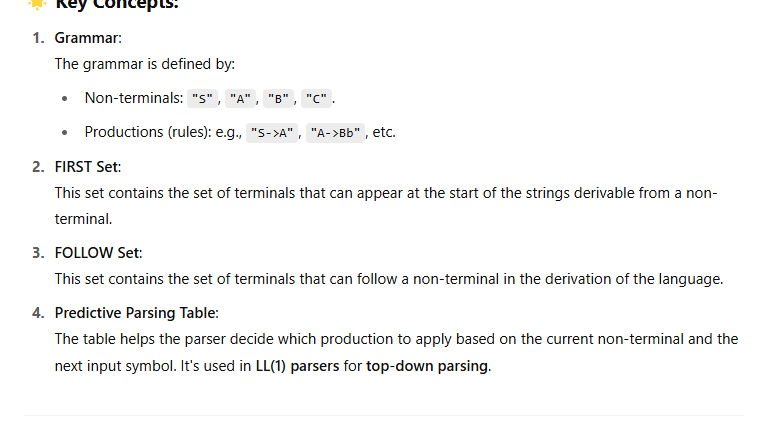

EXPT-4
Aim:  Write a program to implement Lexical Analyzer for given language using Finite Automata.

In [ ]:
def analyze(line):
    i = 0
    length = len(line)

    print("\nLexical Tokens:")
    while i < length:
        ch = line[i]

        if ch.isspace():
            i += 1
            continue

        # Identifier or Keyword
        if ch.isalpha():
            identifier = ''
            while i < length and (line[i].isalnum()):
                identifier += line[i]
                i += 1
            if identifier in ['int', 'float', 'if', 'else']:
                print(f"<Keyword, {identifier}>")
            else:
                print(f"<Identifier, {identifier}>")

        # Number
        elif ch.isdigit():
            number = ''
            while i < length and line[i].isdigit():
                number += line[i]
                i += 1
            print(f"<Number, {number}>")

        # Operator
        elif ch in ['+', '-', '*', '/', '=']:
            print(f"<Operator, {ch}>")
            i += 1

        # Separator
        elif ch in [',', ';', '(', ')', '{', '}']:
            print(f"<Separator, {ch}>")
            i += 1

        # Unknown
        else:
            print(f"<Unknown, {ch}>")
            i += 1

# Main Driver
def main():
    while True:
        input_line = input("Enter a line of input to analyze:\n")
        analyze(input_line)

        choice = input("\nDo you want to analyze another line? (1 = Yes / 0 = No): ")
        if choice != '1':
            break

    print("\nThank you for using the Lexical Analyzer!")

# Run the program
main()


Enter a line of input to analyze:
int main()

Lexical Tokens:
<Keyword, int>
<Identifier, main>
<Separator, (>
<Separator, )>

Do you want to analyze another line? (1 = Yes / 0 = No): 0

Thank you for using the Lexical Analyzer!


🌟 What is a Forward Reference?
When writing assembly code, labels (symbols) are used to mark addresses in the program.
A forward reference happens when you use a label before defining it in the code.

Meaning:

The assembler sees the label being used, but doesn't yet know where (at which address) it will be defined.

So the assembler cannot immediately assign an address or machine code for that instruction.

🌟 Example:
assembly
Copy
Edit
    JMP LOOP_START   ; Forward reference — LOOP_START not yet defined
    MOV A, B
LOOP_START:
    ADD A, 1
At line 1: JMP LOOP_START → Assembler needs address of LOOP_START, but it is defined later.

LOOP_START is defined only after some instructions.

🌟 Why Forward Reference Happens?
Because in assembly programs, labels might be used for jumps, loops, or function calls, and not all code is strictly top-to-bottom.

Programmers write labels naturally in any order.

🌟 How is it Handled?
✅ Two-Pass Assembler:

Pass 1:

Scan the entire program.

Note down the address where each label is defined (create a symbol table).

Pass 2:

Now generate the machine code using the complete symbol table.

So even forward references can be properly resolved because by Pass 2, the assembler knows where every label is.

✅ Single-Pass Assembler (with backpatching):

When encountering a forward reference:

Leave a blank space (a placeholder).

After the label is found, go back and patch (fill) the correct address.

PHASES OF COMPILER
1. Lexical Analysis (Scanner)
Function: Converts the raw source code into tokens, which are the smallest units of meaningful data (e.g., keywords, identifiers, operators).

Output: A stream of tokens.

2. Syntax Analysis (Parser)
Function: Analyzes the token stream produced by the lexical analyzer to ensure that the syntax of the program is correct (according to the grammar rules of the language).

Output: A syntax tree or Abstract Syntax Tree (AST) that represents the hierarchical structure of the program.

3. Semantic Analysis
Function: Ensures that the program has a meaningful interpretation (e.g., type checking, ensuring variables are declared before use).

Output: Annotated AST with semantic information (like types and scopes).

4. Intermediate Code Generation
Function: Converts the AST into an intermediate representation that is easier to manipulate and optimize, typically in a lower-level language or an intermediate form like three-address code.

Output: Intermediate code (e.g., 3-address code, intermediate language).

5. Optimization
Function: Improves the intermediate code by making it more efficient, either in terms of execution speed, memory usage, or both.

Output: Optimized intermediate code.

6. Code Generation
Function: Converts the optimized intermediate code into machine code or assembly code specific to the target architecture.

Output: Assembly or machine code.

7. Code Optimization (Optional)
Function: Further optimization of the machine code to improve performance (e.g., instruction scheduling, register allocation).

Output: Optimized machine code.

8. Code Emission (Code Generation Finalization)
Function: The final machine code is generated, and sometimes linked with other code to form an executable.

Output: Executable or object file.

